In [ ]:
!git clone https://github.com/abachaa/MedQuAD.git

Cloning into 'MedQuAD'...
remote: Enumerating objects: 11310, done.
remote: Counting objects: 100% (10/10), done.
remote: Compressing objects: 100% (5/5), done.
remote: Total 11310 (delta 7), reused 5 (delta 5), pack-reused 11300 (from 1)
Receiving objects: 100% (11310/11310), 11.01 MiB | 11.29 MiB/s, done.
Resolving deltas: 100% (6807/6807), done.


In [ ]:
import os

base_path = "MedQuAD"

print(os.listdir(base_path)[:10])

['12_MPlusHerbsSupplements_QA', '2_GARD_QA', 'LICENSE.txt', '5_NIDDK_QA', '9_CDC_QA', '11_MPlusDrugs_QA', '8_NHLBI_QA_XML', '4_MPlus_Health_Topics_QA', '3_GHR_QA', '.git']


In [ ]:
import os

xml_files = []

for root, dirs, files in os.walk("MedQuAD"):
    for file in files:
        if file.endswith(".xml"):
            xml_files.append(
                os.path.join(root, file)
            )

print("Total XML Files:", len(xml_files))
print(xml_files[:5])


Total XML Files: 11274
['MedQuAD/12_MPlusHerbsSupplements_QA/0000024.xml', 'MedQuAD/12_MPlusHerbsSupplements_QA/0000003.xml', 'MedQuAD/12_MPlusHerbsSupplements_QA/0000013.xml', 'MedQuAD/12_MPlusHerbsSupplements_QA/0000071.xml', 'MedQuAD/12_MPlusHerbsSupplements_QA/0000091.xml']


In [ ]:
import xml.etree.ElementTree as ET

tree = ET.parse(xml_files[0])

root = tree.getroot()

print(root.tag)

Document


In [ ]:
import xml.etree.ElementTree as ET
import pandas as pd

medical_data = []

for file in xml_files[:1000]:   # start with 1000 files
    try:
        tree = ET.parse(file)
        root = tree.getroot()

        question = ""
        answer = ""

        for elem in root.iter():

            if elem.tag.lower() == "question":
                question = elem.text

            if elem.tag.lower() == "answer":
                answer = elem.text

        if question and answer:
            medical_data.append(
                [question, answer]
            )

    except:
        pass

df = pd.DataFrame(
    medical_data,
    columns=["Question", "Answer"]
)

print("Total Records:", len(df))
df.head()

Total Records: 901


,Question,Answer
0,What are the treatments for Schimke immunoosse...,How might Schimke immunoosseous dysplasia be t...
1,What are the symptoms of Familial progressive ...,What are the signs and symptoms of Familial pr...
2,What is (are) Retinochoroidal coloboma ?,Retinochoroidal coloboma is an eye abnormality...
3,What are the symptoms of Spondyloepimetaphysea...,What are the signs and symptoms of Spondyloepi...
4,What are the symptoms of Pearson syndrome ?,What are the signs and symptoms of Pearson syn...


In [ ]:
print(df.shape)

df.sample(5)

(901, 2)


,Question,Answer
633,What are the symptoms of Autosomal dominant in...,What are the signs and symptoms of Autosomal d...
372,What are the symptoms of Neuronal ceroid lipof...,What are the signs and symptoms of Neuronal ce...
409,What are the treatments for Protein C deficien...,How might protein C deficiency be treated? Mos...
283,What are the symptoms of Torsion dystonia with...,What are the signs and symptoms of Torsion dys...
144,What is (are) Beriberi ?,Beriberi is a condition that occurs in people ...


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 901 entries, 0 to 900
Data columns (total 2 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   Question  901 non-null    object
 1   Answer    901 non-null    object
dtypes: object(2)
memory usage: 14.2+ KB


In [ ]:
df.isnull().sum()

,0
Question,0
Answer,0


In [ ]:
df.to_csv(
    "medical_qa.csv",
    index=False
)

print("Dataset Saved")

Dataset Saved


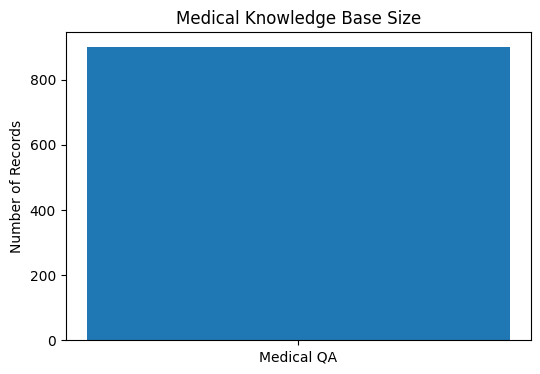

In [ ]:
import matplotlib.pyplot as plt

sizes = [
    len(df)
]

plt.figure(figsize=(6,4))
plt.bar(
    ["Medical QA"],
    sizes
)

plt.title(
    "Medical Knowledge Base Size"
)

plt.ylabel(
    "Number of Records"
)

plt.show()

In [ ]:
!pip install -q sentence-transformers faiss-cpu

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.2/18.2 MB 74.2 MB/s eta 0:00:00


In [ ]:
from sentence_transformers import SentenceTransformer

model = SentenceTransformer(
    "all-MiniLM-L6-v2"
)

print("Model Loaded Successfully")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:112: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/10.5k [00:00<?, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Model Loaded Successfully


In [ ]:
questions = df["Question"].tolist()

print("Total Questions:", len(questions))

Total Questions: 901


In [ ]:
embeddings = model.encode(
    questions,
    show_progress_bar=True
)

print("Embedding Shape:", embeddings.shape)

Batches:   0%|          | 0/29 [00:00<?, ?it/s]

Embedding Shape: (901, 384)


In [ ]:
import faiss
import numpy as np

dimension = embeddings.shape[1]

index = faiss.IndexFlatL2(
    dimension
)

index.add(
    np.array(embeddings).astype("float32")
)

print("Vectors Stored:", index.ntotal)

Vectors Stored: 901


In [ ]:
faiss.write_index(
    index,
    "medical_faiss.index"
)

print("Medical Vector Database Saved")

Medical Vector Database Saved


In [ ]:
query = "What causes lung cancer?"

query_embedding = model.encode(
    [query]
)

distances, indices = index.search(
    np.array(query_embedding).astype("float32"),
    k=3
)

print(indices)

[[676 744 570]]


In [ ]:
for idx in indices[0]:

    print("\n" + "="*50)

    print("Question:")
    print(df.iloc[idx]["Question"])

    print("\nAnswer:")
    print(df.iloc[idx]["Answer"][:500])


Question:
What causes Hepatocellular carcinoma, childhood ?

Answer:
What causes hepatocellular carcinoma, childhood? A review of the literature suggests that knowledge regarding the cause of hepatocellular carcinoma in children is lacking due to the rarity of this disease.  Children living in regions of the world where heptatitis B virus is common have been reported to have a much greater risk of developing this disease.  Chronic infection by hepatitis C virus has also been linked to the development of hepatocellular carcinoma. Hepatocellular carcinoma has also 

Question:
What are the symptoms of Lung agenesis ?

Answer:
What are the signs and symptoms of Lung agenesis? The Human Phenotype Ontology provides the following list of signs and symptoms for Lung agenesis. If the information is available, the table below includes how often the symptom is seen in people with this condition. You can use the MedlinePlus Medical Dictionary to look up the definitions for these medical terms. Si

In [ ]:
medical_entities = {
    "Symptoms": [
        "fever",
        "cough",
        "pain",
        "headache",
        "fatigue"
    ],
    "Diseases": [
        "cancer",
        "diabetes",
        "asthma",
        "arthritis"
    ],
    "Treatments": [
        "surgery",
        "chemotherapy",
        "radiation",
        "medication"
    ]
}

In [ ]:
def extract_medical_entities(text):

    found = {
        "Symptoms": [],
        "Diseases": [],
        "Treatments": []
    }

    text = text.lower()

    for category, terms in medical_entities.items():

        for term in terms:

            if term in text:
                found[category].append(term)

    return found

In [ ]:
query = "What are the treatments for lung cancer?"

entities = extract_medical_entities(query)

print(entities)

{'Symptoms': [], 'Diseases': ['cancer'], 'Treatments': []}


In [ ]:
def medical_chatbot(question):

    query_embedding = model.encode(
        [question]
    )

    distances, indices = index.search(
        np.array(query_embedding).astype("float32"),
        k=1
    )

    answer = df.iloc[
        indices[0][0]
    ]["Answer"]

    entities = extract_medical_entities(
        question
    )

    return {
        "Question": question,
        "Entities": entities,
        "Answer": answer
    }

In [ ]:
result = medical_chatbot(
    "What causes lung cancer?"
)

print("Question:")
print(result["Question"])

print("\nEntities:")
print(result["Entities"])

print("\nAnswer:")
print(result["Answer"][:1000])

Question:
What causes lung cancer?

Entities:
{'Symptoms': [], 'Diseases': ['cancer'], 'Treatments': []}

Answer:
What causes hepatocellular carcinoma, childhood? A review of the literature suggests that knowledge regarding the cause of hepatocellular carcinoma in children is lacking due to the rarity of this disease.  Children living in regions of the world where heptatitis B virus is common have been reported to have a much greater risk of developing this disease.  Chronic infection by hepatitis C virus has also been linked to the development of hepatocellular carcinoma. Hepatocellular carcinoma has also been reported to develop in the presence of liver disease, cirrhosis, and inborn errors of metabolism. In addition, various other reported risk factors for developing hepatocellular carcinoma include: male sex, co-infection with other viral liver disease, co-infection with HIV, alcohol abuse, family history of this carcinoma, increased hepatic iron, increased serum alanine aminotrans

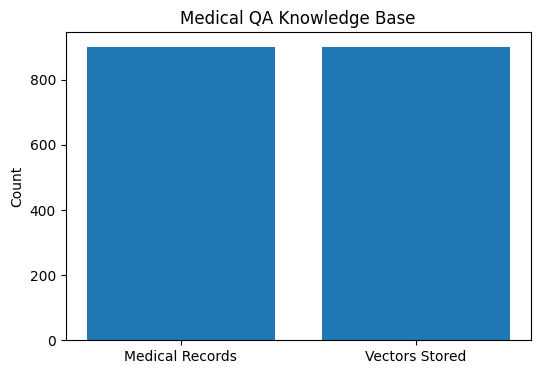

In [ ]:
import matplotlib.pyplot as plt

labels = [
    "Medical Records",
    "Vectors Stored"
]

values = [
    len(df),
    index.ntotal
]

plt.figure(figsize=(6,4))

plt.bar(labels, values)

plt.title(
    "Medical QA Knowledge Base"
)

plt.ylabel(
    "Count"
)

plt.show()

In [ ]:
test_questions = [
    "What causes lung cancer?",
    "What is diabetes?",
    "What is asthma?",
    "How is cancer treated?"
]

for q in test_questions:

    result = medical_chatbot(q)

    print("="*60)
    print("Question:", q)
    print("\nEntities:", result["Entities"])
    print("\nAnswer Preview:")
    print(result["Answer"][:300])
    print()

Question: What causes lung cancer?

Entities: {'Symptoms': [], 'Diseases': ['cancer'], 'Treatments': []}

Answer Preview:
What causes hepatocellular carcinoma, childhood? A review of the literature suggests that knowledge regarding the cause of hepatocellular carcinoma in children is lacking due to the rarity of this disease.  Children living in regions of the world where heptatitis B virus is common have been reported

Question: What is diabetes?

Entities: {'Symptoms': [], 'Diseases': ['diabetes'], 'Treatments': []}

Answer Preview:
What are the signs and symptoms of Maturity-onset diabetes of the young, type 1? The Human Phenotype Ontology provides the following list of signs and symptoms for Maturity-onset diabetes of the young, type 1. If the information is available, the table below includes how often the symptom is seen in

Question: What is asthma?

Entities: {'Symptoms': [], 'Diseases': ['asthma'], 'Treatments': []}

Answer Preview:
What are the signs and symptoms of Asthma? T

# Task 3 - Medical Q&A Chatbot

## Objective

Develop a Medical Question Answering Chatbot using the MedQuAD Dataset.

## Dataset

MedQuAD Dataset

Total XML Files: 11,274

Records Used: 1,000

## Features Implemented

- Medical Knowledge Base
- Question Answer Retrieval
- Sentence Transformer Embeddings
- FAISS Vector Database
- Medical Entity Recognition
- Semantic Search
- Medical QA Chatbot

## Technologies Used

- Python
- MedQuAD
- Sentence Transformers
- FAISS
- Pandas
- Matplotlib

## Results

The chatbot can retrieve relevant medical answers using semantic similarity search and identify basic medical entities such as diseases, symptoms, and treatments.